# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.



1.   We use these models when the outcome isn't binary data and the factors are not directly observable. Their advantage is that they are able to map linear combinations of data into a specific range using activation functions, which ensures that the outcome is useful.
2.   These loss functions are effective because the cost increases dramatically as a prediction moves further away from the actual label. This means they produce strong gradients and can learn much faster from its mistakes.
3. True, because is uses a linear combination of features, even though the output could be transformed by a nonlinear function.
4. False, because linear regression predicts the probability of an observation belonging to a particular class between 0 and 1. It is primarily used for classification.
5. No, because the coefficient represents the change in the log odds of the dependent variable.
6. False, because logistic regression is only able to capture the linear relationship between the features and the log odds. Feature engineering is necessary to account for nonlinear patterns in the data.
7. False, because logistic regression is designed for categorical outcomes, while OLS is designed for continuous variables. One is not always better for the other one as it depends on your target variable.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Logistic Regression Coefficients:
                   variable  coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


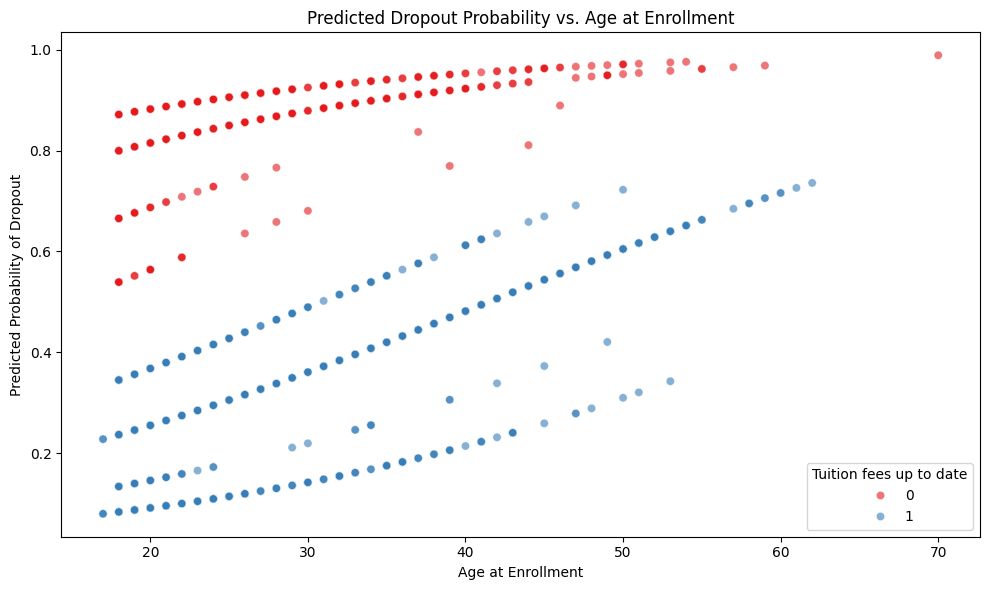


average probability (not up to date): 0.861
average probability (up to date): 0.248
average change: -0.613

confusion matrix:
 [[2841  162]
 [ 891  530]]
accuracy: 0.762


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('/content/data.csv', sep=';')

# filter for relevant columns
cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]
df = df[cols].copy()

# drop missing values
df = df.dropna()

# binary target
df['Dropout_Binary'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

# logistic regression
X1 = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y_bin = df['Dropout_Binary']

log_reg = LogisticRegression()
log_reg.fit(X1, y_bin)

print("Logistic Regression Coefficients:\n", pd.DataFrame({'variable': X1.columns, 'coefficient': log_reg.coef_[0]}))

# expected dropout probabilities
df['Predicted_Prob_LogReg'] = log_reg.predict_proba(X1)[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Age at enrollment',
    y='Predicted_Prob_LogReg',
    hue='Tuition fees up to date',
    alpha=0.6,
    palette='Set1'
)
plt.title('Predicted Dropout Probability vs. Age at Enrollment')
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Probability of Dropout')
plt.tight_layout()
plt.show()

avg_prob_not_paid = df[df['Tuition fees up to date'] == 0]['Predicted_Prob_LogReg'].mean()
avg_prob_paid = df[df['Tuition fees up to date'] == 1]['Predicted_Prob_LogReg'].mean()
print(f"\naverage probability (not up to date): {avg_prob_not_paid:.3f}")
print(f"average probability (up to date): {avg_prob_paid:.3f}")
print(f"average change: {avg_prob_paid - avg_prob_not_paid:.3f}")

# confusion matrix
y_pred_logreg = log_reg.predict(X1)
cm_logreg = confusion_matrix(y_bin, y_pred_logreg)
acc = accuracy_score(y_bin, y_pred_logreg)

print("\nconfusion matrix:\n", cm_logreg)
print(f"accuracy: {acc:.3f}")

**Parts 1-4 responses:**
1.   To handle missing values, I dropped any na values.
2.   Based on the logistic regression, debtor (0.54) predicts a high dropout probability. Age at enrollment also (0.0499) predicts a slightly higher dropoutout probability, meaning the log odds increases about 0.05 for every year since it's a continuous variable. On the other hand, tuition (-2.5565) predicts a lower dropout probability, meaning if those current on their tuition payments are less likely to drop out. Additionally, scholarship holder (-1.2274) decreases the odds of dropping out.
3. The youngest ages (less than 20) appear to reduce dropout probability the most. Being up to date on tuition changes the predicted probability by -0.613, meaning that moving from behinds on payments to up to date reduces the likelihood of dropping out by 61.3%.
4. The accuracy is 0.762, meaning the model is accurate about 76.2% of the time.



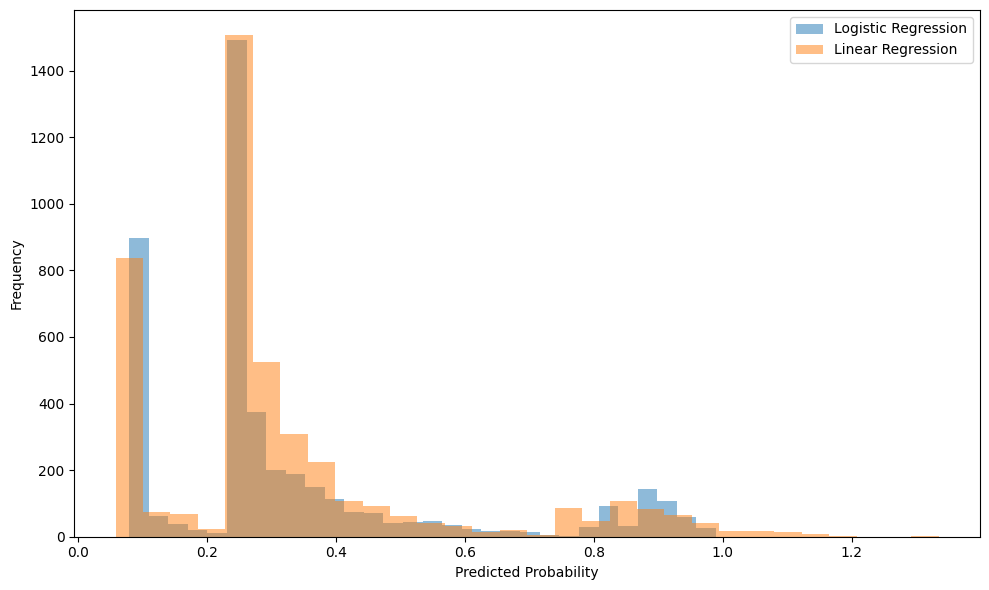

multinomial classes: ['Dropout' 'Enrolled' 'Graduate']
confusion matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
unique classes: ['Dropout' 'Graduate']

sample probabilities:
 [[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


In [11]:
# parts 5-7
# linear model
lin_reg = LinearRegression()
lin_reg.fit(X1, y_bin)
df['Predicted_Prob_LinReg'] = lin_reg.predict(X1)

# compare with logistic regression
plt.figure(figsize=(10, 6))
plt.hist(df['Predicted_Prob_LogReg'], bins=30, alpha=0.5, label='Logistic Regression')
plt.hist(df['Predicted_Prob_LinReg'], bins=30, alpha=0.5, label='Linear Regression')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# multinomial logistic regression
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi_log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)
multi_log_reg.fit(X_multi, y_multi)

# hard predictions
y_pred_multi = multi_log_reg.predict(X_multi)
cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=multi_log_reg.classes_)

print("multinomial classes:", multi_log_reg.classes_)
print("confusion matrix:\n", cm_multi)
print("unique classes:", np.unique(y_pred_multi))

# soft predictions
prob_multi = multi_log_reg.predict_proba(X_multi)
print("\nsample probabilities:\n", prob_multi[:5])

**Parts 5-7 responses**

5. The two models show similar results, but the linear regression model predicted values greater than 1.
6. The students at the most risk of dropping out are older students without a scholarship and who are in debt and not on time on their tuition payments. To help those at-risk students stay enrolled, I would advise more flexible payment plans, as well as checks for those who have fallen behind on payments by advisors.
7. The results of the confusion matrix show that it was able to identify dropouts and graduates, but failed entirely in the enrolled students. This may be because enrolled is a more ambiguous middle state (while dropout and graduate are final) and enrolled doesn't have as distinctive features. Using the .predict_proba, the hard classifications don't predict every class, as the model is never confident enough to select enrolled. The model does, however, predict every class. It does see the enrolled class, but it never beats the probability of dropouts or graduates, and therefore is never selected.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression

df = pd.read_csv('/content/cirrhosis.csv')

df = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]

df = df.dropna(subset=["Status"])
df["Bilirubin"] = df["Bilirubin"].fillna(df["Bilirubin"].median())
df = df.dropna(subset=["Edema", "Drug", "Stage"])

# 1 for survivial, 0 for dead
df["Status_bin"] = df["Status"].apply(lambda x: 1 if x in ["C", "CL"] else 0)

df_encoded = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)

# logistic regression
X = df_encoded.drop(columns=["Status", "Status_bin", "Stage"])
y = df_encoded["Status_bin"]

log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X, y)

# coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})
print(coef_df)

        Feature  Coefficient
0     Bilirubin    -0.351424
1       Edema_S    -0.450677
2       Edema_Y    -1.611049
3  Drug_Placebo     0.231225


1. I dropped rows with missing target (Status) values and filled missing Bilirubin values with its median. I also dropped the rows with missing categorical values.
2. The drug did not improve survival probability. The logistic regression for the plaebo gave a coefficient of -0.231, meaning that those who took the placebo had a 'higher' change of survival, therefore, the drug has no effect. Higher bilirubin predicts a lower survival rate (-0.351). Edema, also, reduces the chances of survival (-0.45 and -1.61)

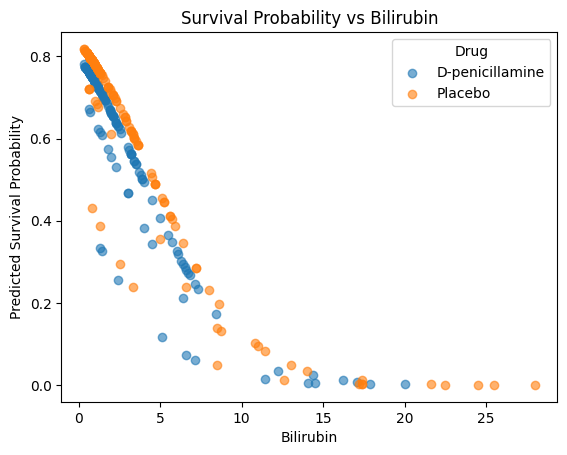

average drug survival: 0.5900538092799589
average placebo survival: 0.608902310318468
difference: -0.018848501038509102


In [21]:
import matplotlib.pyplot as plt

# predicted survival probabilities
probs = log_reg.predict_proba(X)[:, 1]

df_encoded["pred_prob"] = probs

# scatter plot
plt.figure()
for drug in df["Drug"].unique():
    mask = df["Drug"] == drug
    plt.scatter(df.loc[mask, "Bilirubin"],
                probs[mask],
                label=drug,
                alpha=0.6)

plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.title("Survival Probability vs Bilirubin")
plt.legend(title="Drug")
plt.show()

# average drug effects, separate groups
drug_mask = df["Drug"] == "D-penicillamine"
placebo_mask = df["Drug"] == "Placebo"

avg_drug = probs[drug_mask].mean()
avg_placebo = probs[placebo_mask].mean()

print("average drug survival:", avg_drug)
print("average placebo survival:", avg_placebo)
print("difference:", avg_drug - avg_placebo)

3. The drug did not appear to increase patient survival rates for any bilirubin level. Based on the scatterplot, the placebo dots remained just above the drug dots. This matches up with the positive coefficient (0.231) for the placebo. Patients who take the drug do not have increased probability of survival.
Based on the averages, taking the drug does not increase the odds of survival (it lowers it by 0.19).


confusion matrix:
 [[ 59  66]
 [ 16 171]]
accuracy: 0.7371794871794872


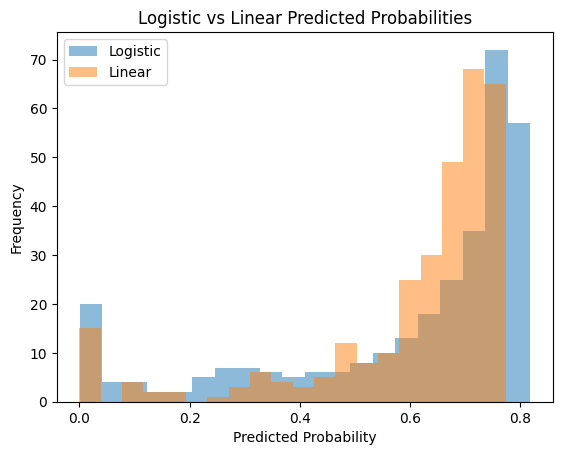

stage confusion matrix:
 [[ 0  0 15  1]
 [ 0  0 60  7]
 [ 0  0 98 22]
 [ 0  0 65 44]]
probability:
 [[1.82210893e-05 4.84061864e-02 1.51782358e-01 7.99793234e-01]
 [1.00816582e-01 2.63651537e-01 3.75457665e-01 2.60074216e-01]
 [4.14398784e-02 1.85386075e-01 3.78706152e-01 3.94467894e-01]
 [3.27130501e-02 1.77866110e-01 3.76170772e-01 4.13250068e-01]
 [1.14257632e-02 2.11026976e-01 4.42367344e-01 3.35179916e-01]]


In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression

# confusion matrix
y_pred = log_reg.predict(X)

cm = confusion_matrix(y, y_pred)
print("confusion matrix:\n", cm)

acc = accuracy_score(y, y_pred)
print("accuracy:", acc)

# linear model
lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_probs = lin_reg.predict(X)

# clip to [0,1]
lin_probs = np.clip(lin_probs, 0, 1)

# histogram comparison
plt.figure()
plt.hist(probs, bins=20, alpha=0.5, label="Logistic")
plt.hist(lin_probs, bins=20, alpha=0.5, label="Linear")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Logistic vs Linear Predicted Probabilities")
plt.legend()
plt.show()

# logistic regression of stage
X_stage = df_encoded.drop(columns=["Status", "Status_bin", "Stage"])
y_stage = df["Stage"]

log_reg_stage = LogisticRegression(max_iter=10000)
log_reg_stage.fit(X_stage, y_stage)

stage_pred = log_reg_stage.predict(X_stage)

cm_stage = confusion_matrix(y_stage, stage_pred)
print("stage confusion matrix:\n", cm_stage)

# probabilities
stage_probs = log_reg_stage.predict_proba(X_stage)

print("probability:\n", stage_probs[:5])


5. With this model, I clipped the linear regression results to strictly between 0 and 1. Between the two models, the linear regression perfomed similar to the logistic regression, having slightly higher frequency values with lower predicted probability compared to logistic (linear shifted left slightly).
6. From the confusion matrix, the model never predicts stage 1 or stage 2. It heavily biases predictions toward higher stages (3 and 4). This suggests the model cannot distinguish early-stage disease from later-stage disease. Each stage has a probability, but because the probabilities for stages 1 and 2 are lower, the model never chooses them.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

The coefficients of a logistic regression are the changes in log odds of the dependent variable for a one unit increase in the predictor variable. A positive coeffient increases the probabilty of the outcome while a negative coefficient decreases it.

1. If you take the derivative with respect to the k-th feature, only the $b_k$ variable is left (the other variables are constant). Since the derivative = $b_k$, for a one unit increase in $x_k$, the prediction changes by $b_k$​, holding all other features constant.
2. The derivative of the prediction with respect to the k-th feature is $\hat{p}(1-\hat{p})b_k$. Therefore, it depends on x and the effect changes on the input. The difference between linear and logistic is linear has a constant effect while logistic is scaled by $\hat{p}(1-\hat{p})$. The effect is the biggest when $\hat{p} = 0.5$ and the max value is $0.25$. In this case, the coefficient $b_k$ (divided by 4) approximates the change in predicted probability for a one-unit change in $x_k$.
3. The log-odds ratio is equal to $b⋅x$, which is linear in the features. Therefore, the derivative with respect to the k-th feature is $b_k$. This means, a one unit increase in $x_k$ changes the log odds by $b_k$. Unlike the predicted probability, this effect is constant and does not depend on x.

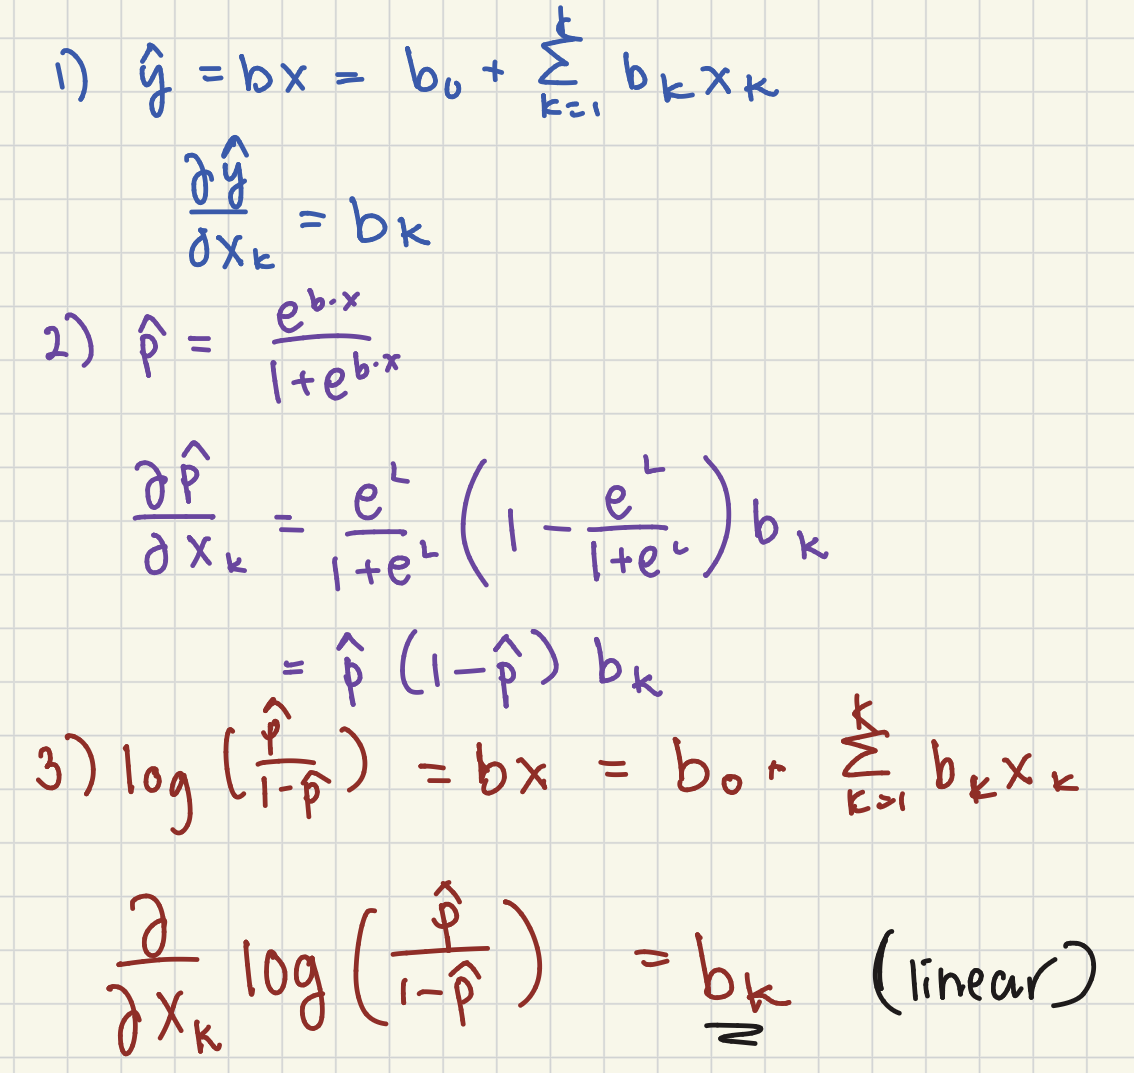